# Predicting Alzheimer's Disease via Machine Learning Models

### Project Overview

In this project I Investigate a synthetic clinical dataset to see what machine learning models perform better in predicting the Alzheimer's disease, and which features are most associated with an Alzheimer's diagnosis. The plan is to start with some basic data exploration and then try out a few standard machine learning models.

**Dataset:** Rabie El Kharoua. (2024). 🧠 Alzheimer's Disease Dataset 🧠 [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/8668279

The dataset used is a synthetic collection from Kaggle. While not real-world patient data, it provides a clean, well-structured environment to explore various classification techniques and establish an analysis workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('alzheimers_disease_data.csv')
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [4]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

### 1. Initial Data Cleaning

In [5]:
# drop useless columns
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)
df.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


In [6]:
df.duplicated().sum()

np.int64(0)

There are no duplicate entries in the dataset.

`df.info()` output doesn't show all the columns; so we should check for missing values in another way.

In [7]:
missing_values = df.isnull().sum(axis=0)
missing_values[missing_values > 0]

Series([], dtype: int64)

There are no missing values in the dataset; however we should also check for sentinel values (special codes sometimes used to denote missingness), and integrity of the dataset as well.

In [8]:
# validate every column against its expected values as defined in the data dictionary.

validation_rules = {
    # Demographics
    'Age': ('range', 60, 90),
    'Gender': ('binary',),
    'Ethnicity': ('categorical', {0, 1, 2, 3}),
    'EducationLevel': ('categorical', {0, 1, 2, 3}),
    # Lifestyle
    'BMI': ('range', 15, 40),
    'Smoking': ('binary',),
    'AlcoholConsumption': ('range', 0, 20),
    'PhysicalActivity': ('range', 0, 10),
    'DietQuality': ('range', 0, 10),
    'SleepQuality': ('range', 4, 10),
    # Medical History
    'FamilyHistoryAlzheimers': ('binary',),
    'CardiovascularDisease': ('binary',),
    'Diabetes': ('binary',),
    'Depression': ('binary',),
    'HeadInjury': ('binary',),
    'Hypertension': ('binary',),
    # Clinical Measurements
    'SystolicBP': ('range', 90, 180),
    'DiastolicBP': ('range', 60, 120),
    'CholesterolTotal': ('range', 150, 300),
    'CholesterolLDL': ('range', 50, 200),
    'CholesterolHDL': ('range', 20, 100),
    'CholesterolTriglycerides': ('range', 50, 400),
    # Assessments & Symptoms
    'MMSE': ('range', 0, 30),
    'FunctionalAssessment': ('range', 0, 10),
    'MemoryComplaints': ('binary',),
    'BehavioralProblems': ('binary',),
    'ADL': ('range', 0, 10),
    'Confusion': ('binary',),
    'Disorientation': ('binary',),
    'PersonalityChanges': ('binary',),
    'DifficultyCompletingTasks': ('binary',),
    'Forgetfulness': ('binary',),
    # Diagnosis
    'Diagnosis': ('binary',)
}

for col, rule in validation_rules.items():
    rule_type = rule[0]
    
    if rule_type == 'binary':
        unique_vals = set(df[col].unique())
        if not unique_vals.issubset({0, 1}):
            print(f"{rule_type} '{col}' has unexpected values: {unique_vals}")
            
    elif rule_type == 'categorical':
        unique_vals = set(df[col].unique())
        expected_set = rule[1]
        if not unique_vals.issubset(expected_set):
            print(f"{rule_type} '{col}' has unexpected values: {unique_vals}")
            
    elif rule_type == 'range':
        min_val, max_val = df[col].min(), df[col].max()
        min_exp, max_exp = rule[1], rule[2]
        if min_val < min_exp or max_val > max_exp:
            print(f"{rule_type} '{col}' out of range: {min_val}-{max_val}")


As we can see there are no sentinel values or unexpected values;

### 2. Exploratory Data Analysis (EDA)

#### Target Variable Distribution

In [9]:
print(df['Diagnosis'].value_counts())
print()
print(df['Diagnosis'].value_counts(normalize=True))

Diagnosis
0    1389
1     760
Name: count, dtype: int64

Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64


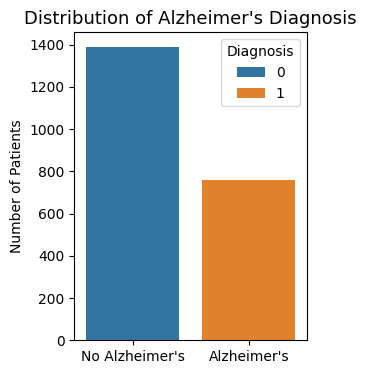

In [10]:
plt.figure(figsize=(3, 4))
sns.countplot(x='Diagnosis', data=df, hue='Diagnosis')

plt.title('Distribution of Alzheimer\'s Diagnosis', fontsize=13)
plt.ylabel('Number of Patients')
plt.xlabel('')
plt.xticks(ticks=[0, 1], labels=["No Alzheimer's", "Alzheimer's"])
plt.show()

The dataset shows a moderate class imbalance. There are 1389 patients in the control group, and 760 patients in the diagnosed group, which is roughly a 65/35 split; this imbalance is something to be mindful of during modeling. Standard accuracy could be a misleading metric. For example, a model that always predicts "No Alzheimer's" would still be 65% accurate.

#### Distribution of Numerical Features

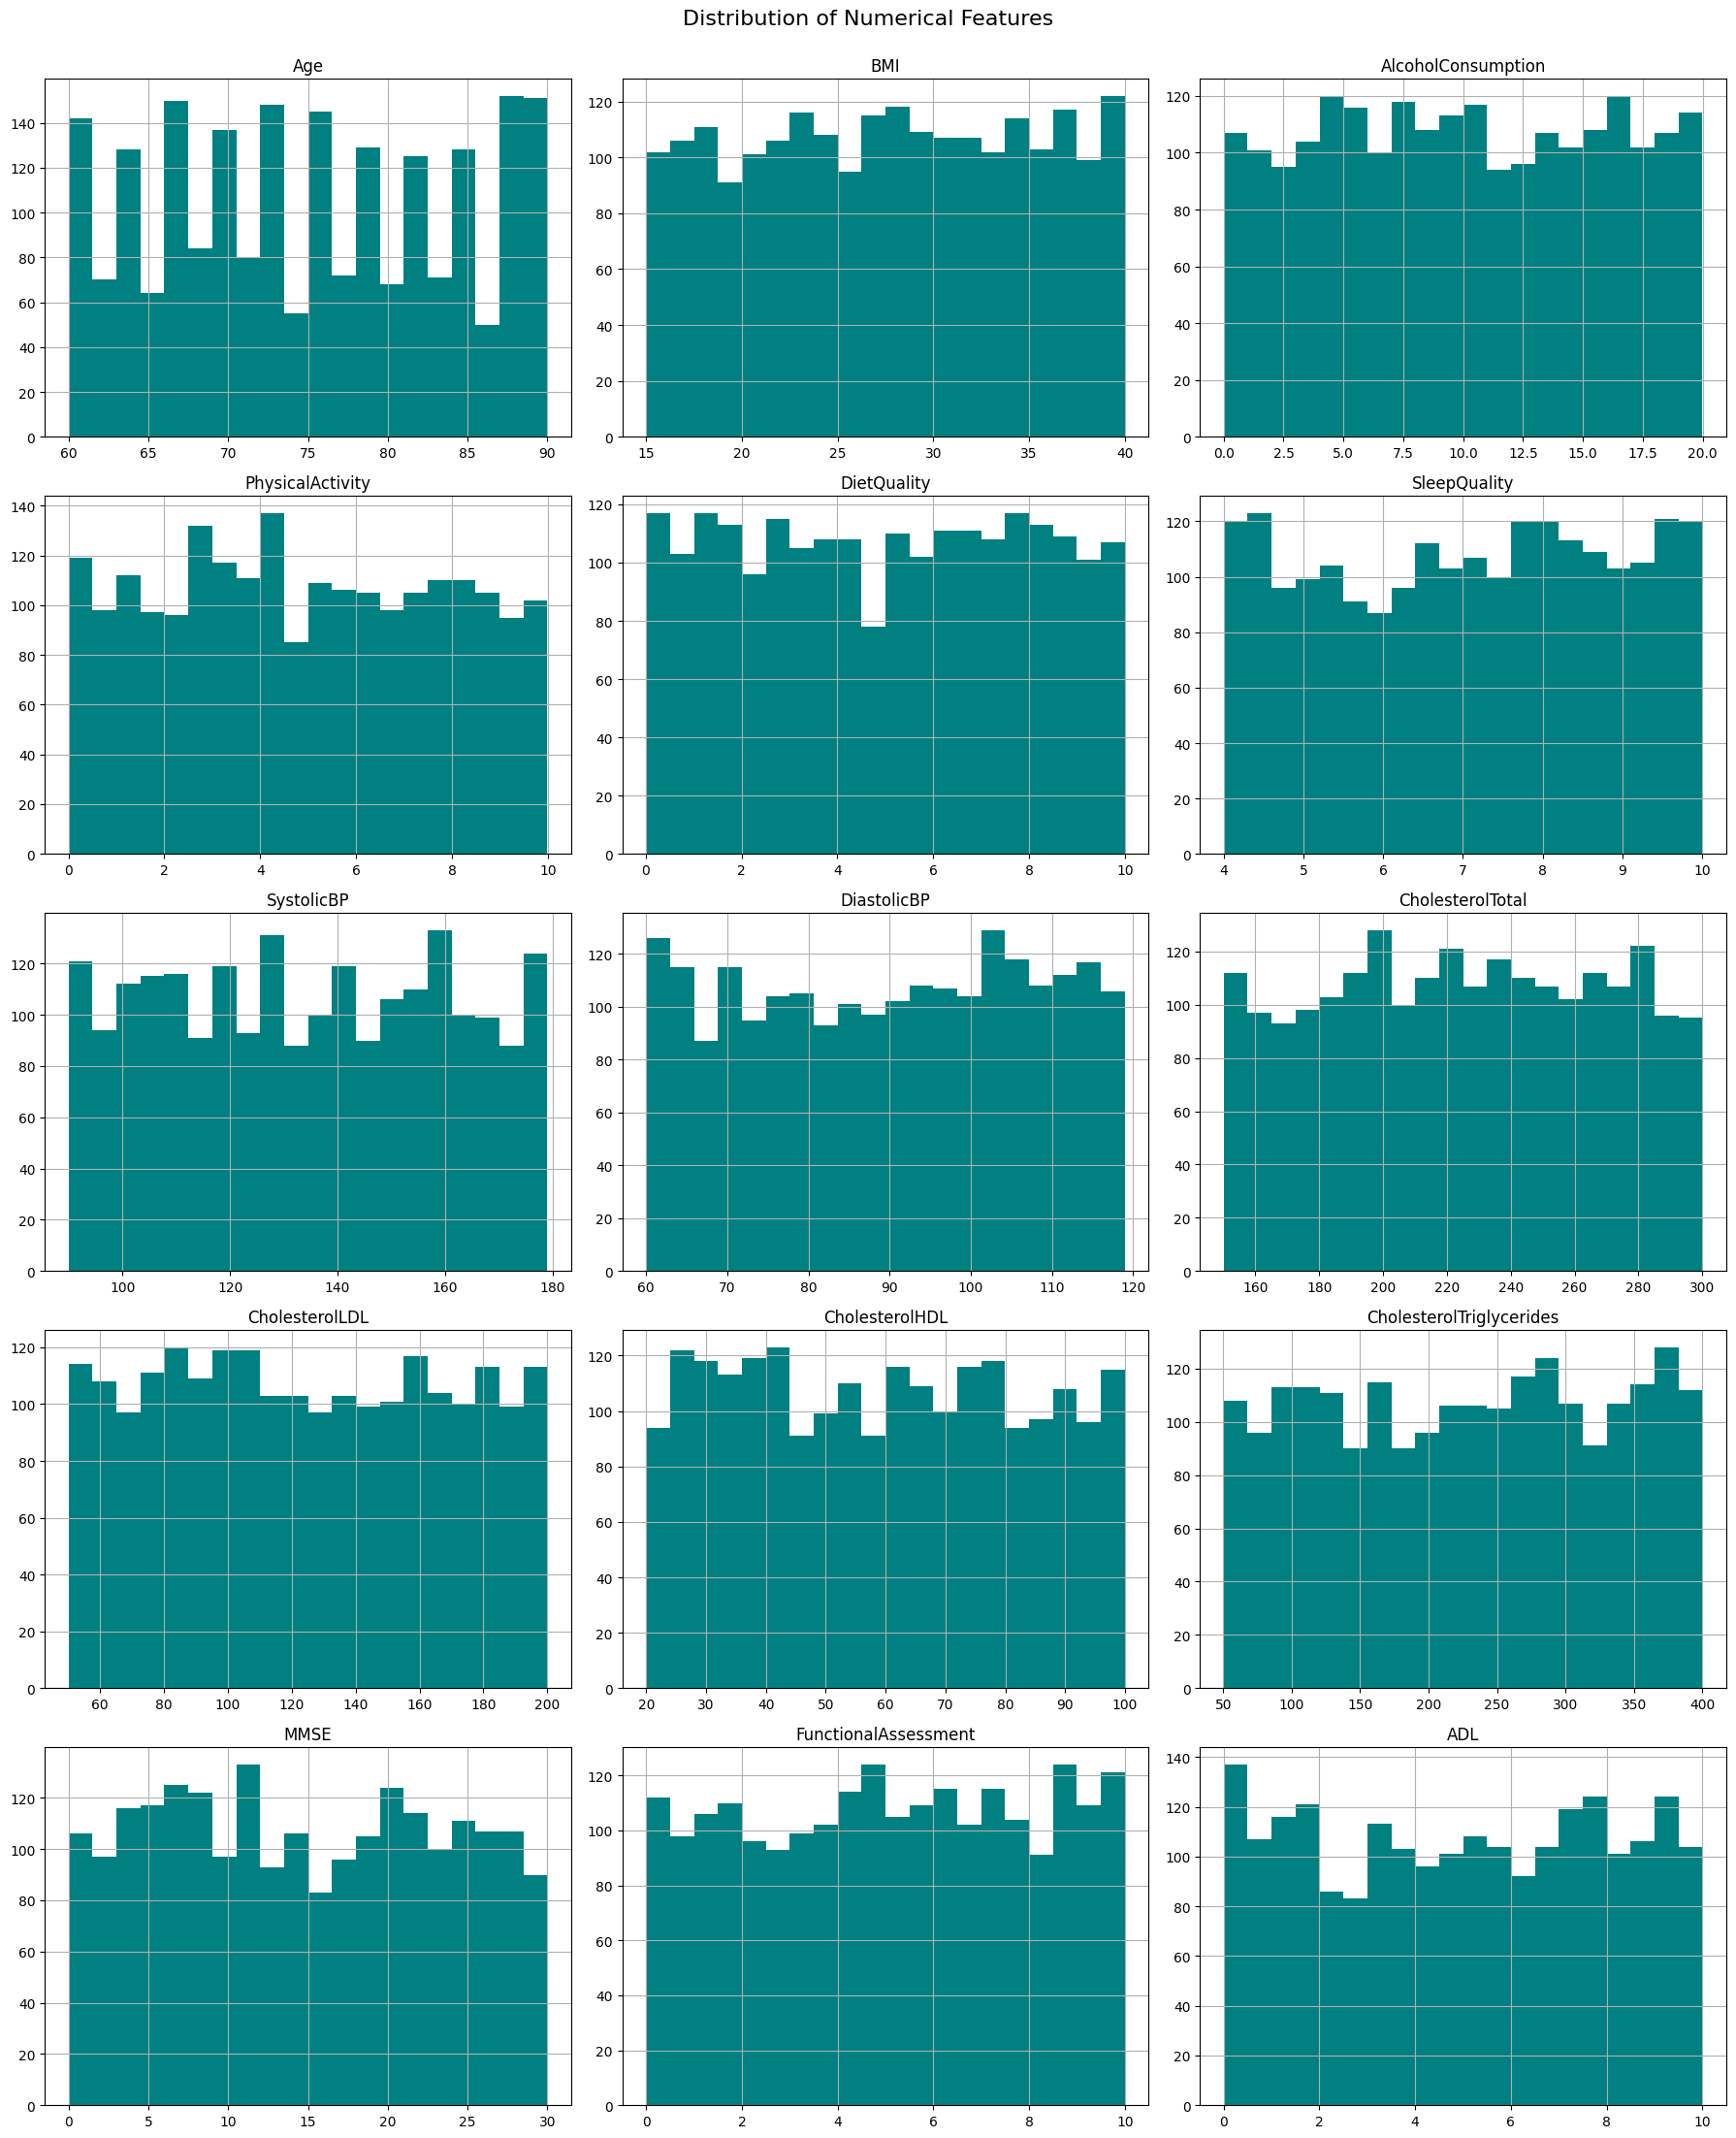

In [11]:
numerical_features = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL'
]

df[numerical_features].hist(bins=20, figsize=(18, 22), layout=(-1,3), color="teal")
plt.suptitle('Distribution of Numerical Features', y=1.0, fontsize=16)
plt.tight_layout()
plt.show()

**Observations from Histograms:**\
The unexpected finding from these plots is that nearly all the numerical features follow an approximately uniform distribution. Features like Age, BMI do not show the expected normal or skewed distributions that are typical of realworld data...

#### Distribution of Categorical Features

In [12]:
categorical_features = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'FamilyHistoryAlzheimers',
    'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

# nrows = int(np.ceil(len(categorical_features)/3))
# fig, axes = plt.subplots(ncols=3, nrows=nrows, figsize=(16, 22))
# axes = axes.flatten()

# for i, col in enumerate(categorical_features):
#     counts = df[col].value_counts()
#     axes[i].pie(counts.values, labels=counts.index, autopct='%1.1f%%')
#     axes[i].set_title(col)

# # remove unused subplot cells
# for j in range(len(categorical_features), len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

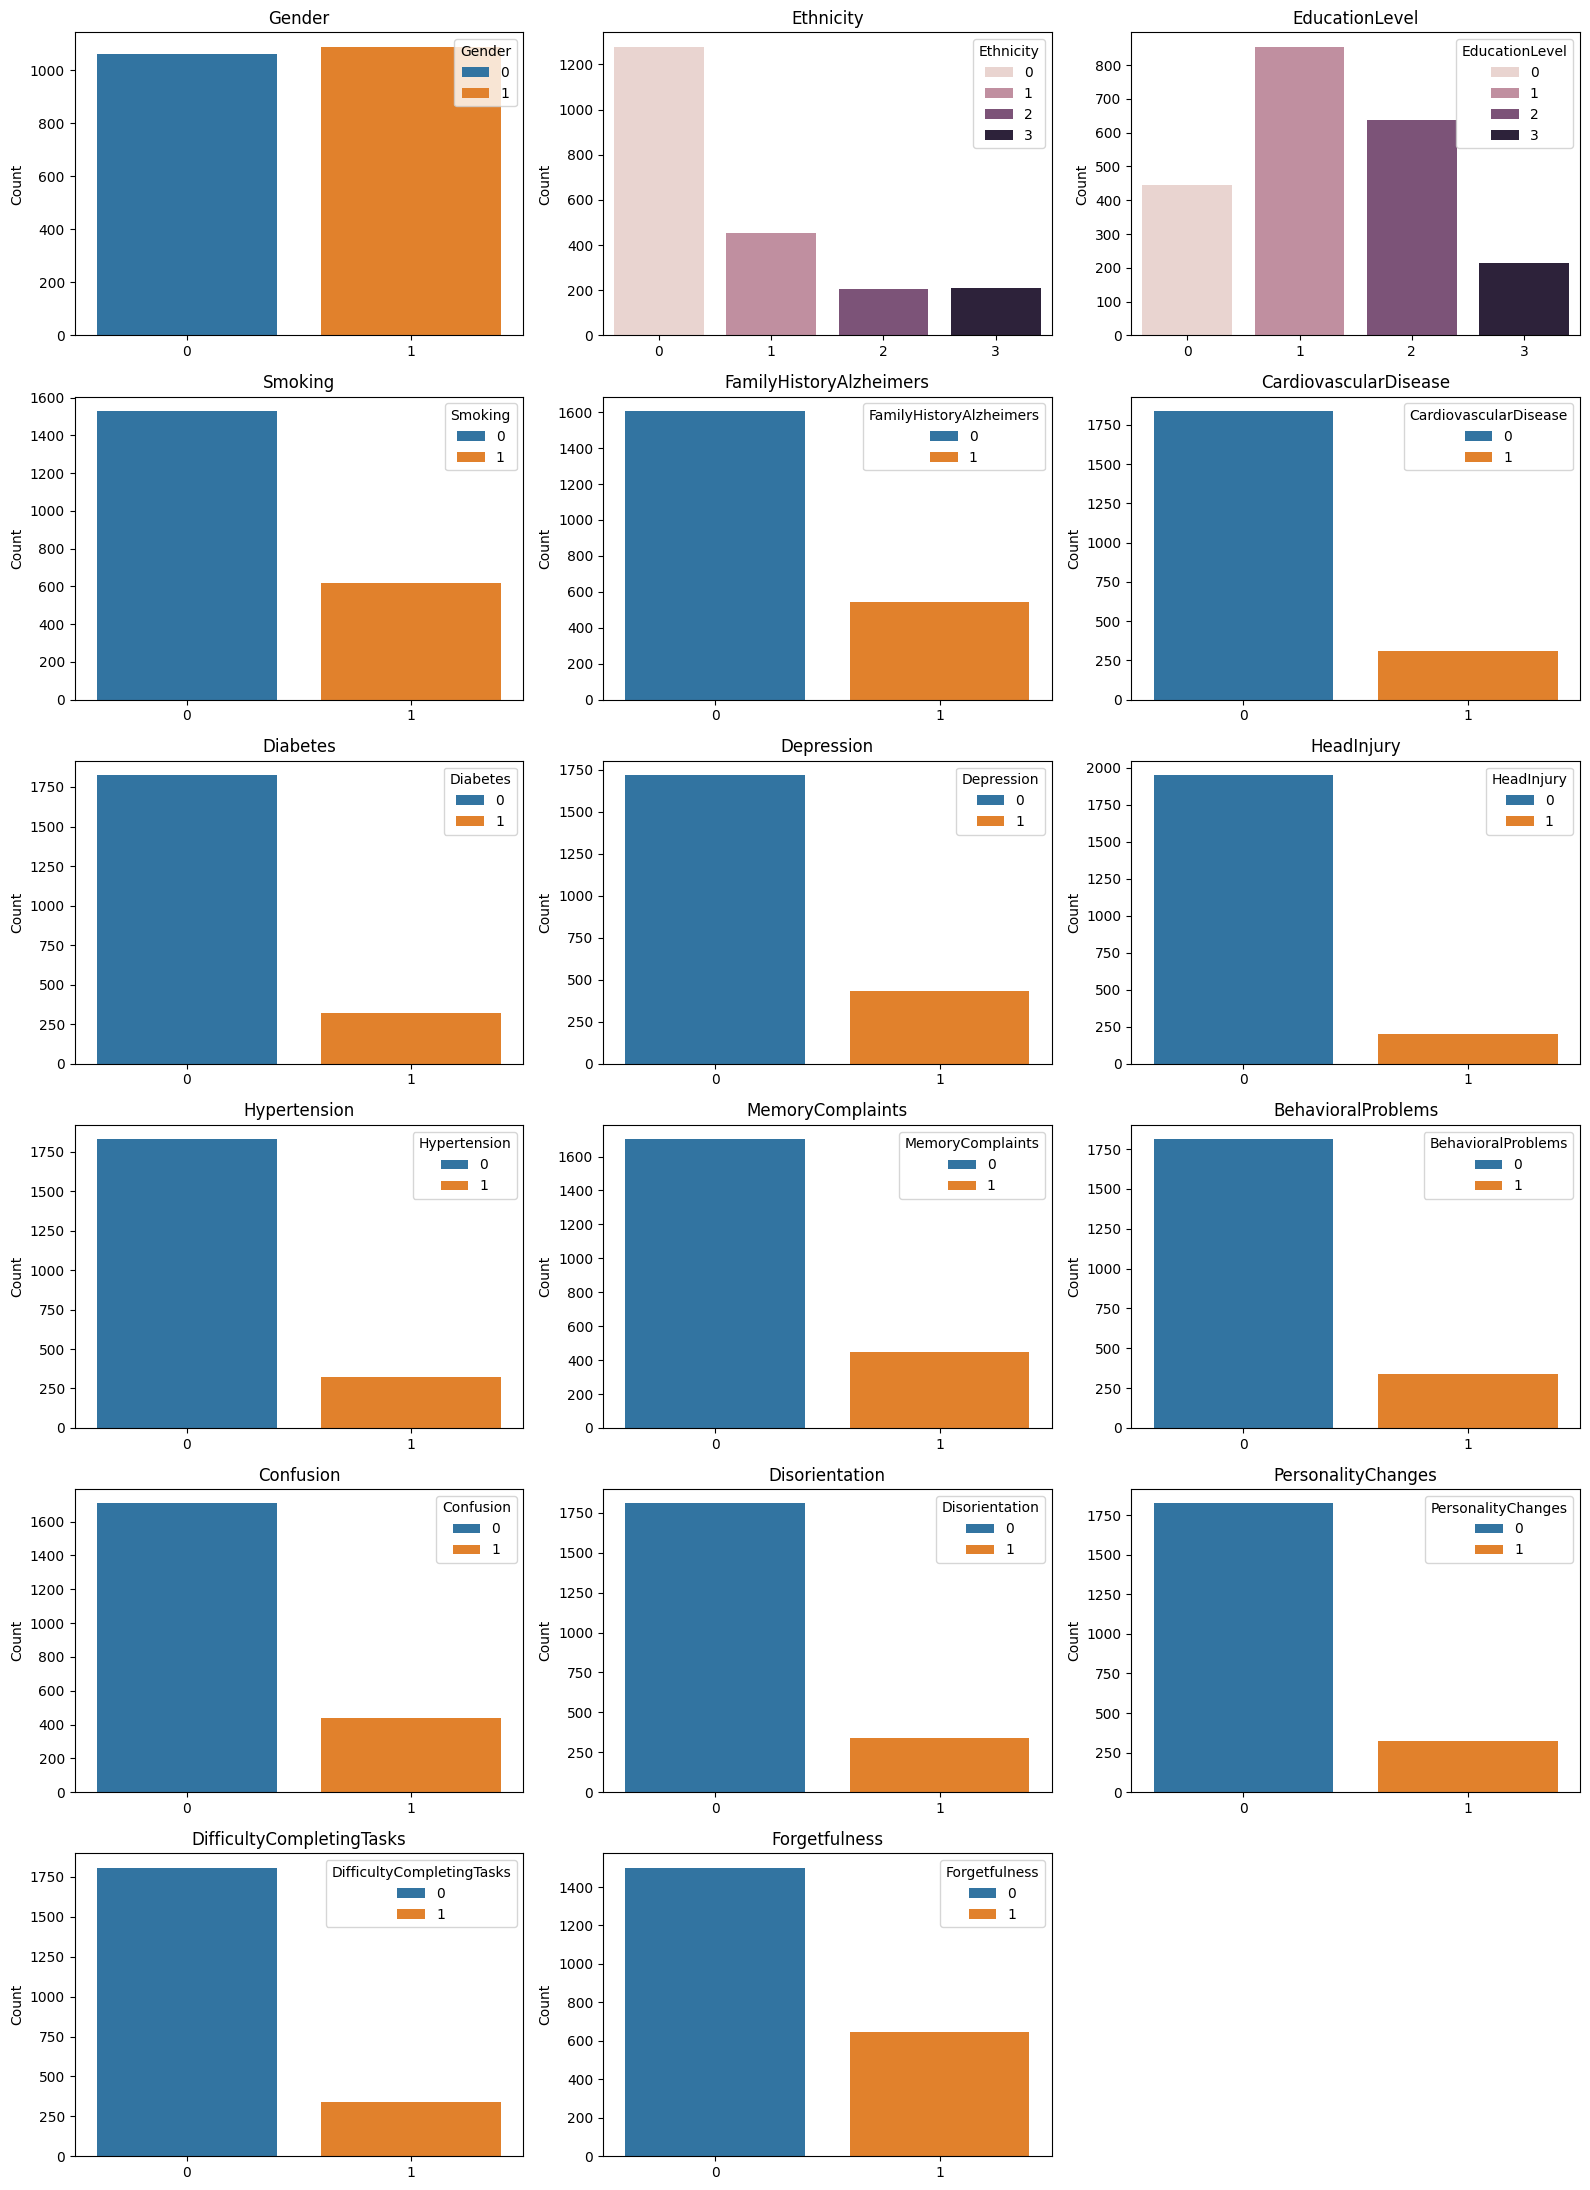

In [13]:
nrows = int(np.ceil(len(categorical_features)/3))
fig, axes = plt.subplots(ncols=3, nrows=nrows, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=df, ax=axes[i], hue=col)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Categorical Distributions:**
- Demographics: Gender is perfectly balanced. Ethnicity is dominated by category 0 (Caucasian), while EducationLevel shows most patients falling into categories 1 and 2 (High school / Bachelors).
- Medical History & Symptoms: All binary medical flags (like Diabetes, Hypertension, Depression) and symptom flags (like Confusion, Forgetfulness) are heavily skewed towards 0 (absent). Conditions like HeadInjury are particularly rare in this dataset. 
- This skewness in binary features is common in clinical data, where the presence of specific pathologies or symptoms is less frequent than their absence.